In [43]:
%pip install matplotlib seaborn scipy

import pandas as pandas
import numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
df = sns.load_dataset('iris')
print(df.shape)
print(df.dtypes)
print(df.head(5))
print(df.describe().round(3))

(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100       

In [45]:
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f' Mean : {col.mean():.3f}')
    print(f' Median : {col.median():.3f}')
    print(f' Std Dev : {col.std():.3f}')
    print(f' Skewness : {col.skew():.3f}')
    print(f' Kurtosis : {col.kurt():.3f}')


=== sepal_length ===
 Mean : 5.843
 Median : 5.800
 Std Dev : 0.828
 Skewness : 0.315
 Kurtosis : -0.552

=== sepal_width ===
 Mean : 3.057
 Median : 3.000
 Std Dev : 0.436
 Skewness : 0.319
 Kurtosis : 0.228

=== petal_length ===
 Mean : 3.758
 Median : 4.350
 Std Dev : 1.765
 Skewness : -0.275
 Kurtosis : -1.402

=== petal_width ===
 Mean : 1.199
 Median : 1.300
 Std Dev : 0.762
 Skewness : -0.103
 Kurtosis : -1.341


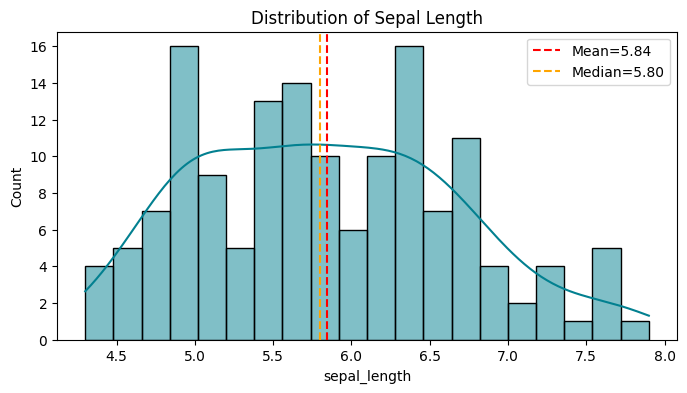

In [46]:
fig,ax = plt.subplots(figsize=(8,4))
sns.histplot(df['sepal_length'], kde=True, ax=ax, bins = 20, color = "#028090")
ax.axvline(df['sepal_length'].mean(), color='red', linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange', linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")
ax.set_title('Distribution of Sepal Length')
ax.legend()
plt.show()

C:\Users\nizzu\AppData\Local\Temp\ipykernel_8624\1495741183.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df , x = 'species', y = 'petal_length', palette = 'Set2', ax = ax[0])
C:\Users\nizzu\AppData\Local\Temp\ipykernel_8624\1495741183.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = df, x = 'species', y = 'petal_length', palette = 'Set2', ax = ax[1])


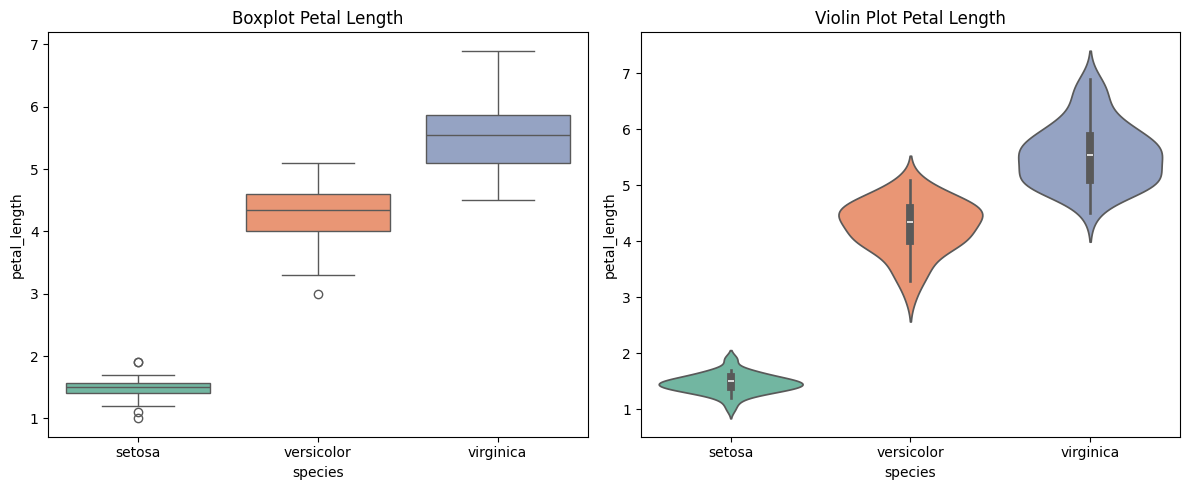

In [47]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

sns.boxplot(data = df , x = 'species', y = 'petal_length', palette = 'Set2', ax = ax[0])
ax[0].set_title('Boxplot Petal Length')

sns.violinplot(data = df, x = 'species', y = 'petal_length', palette = 'Set2', ax = ax[1])
ax[1].set_title('Violin Plot Petal Length')
plt.tight_layout()
plt.show()

#Spesies Terbesar = Virginica
#Spesies Terkecil = Setosa
#Spesies Dengan Sebaran Tertinggi = Versicolor

In [48]:
corr = df.drop(columns='species').corr(method='pearson')
print(corr.round(3))

import numpy as np
mask = np.triu(np.ones_like(corr, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
min_pair = corr_masked.stack().idxmin()

print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')
print(f'Korelasi terendah: {min_pair} = {corr.loc[min_pair]:.3f}')

#Korelasi Tertingi adalah petal_width dengan petal_length, sedangkan terendah adalah antara sepal_length dengan petal_width.
#Hal ini menunjukkan bahwa petal_width dan petal_length memiliki hubungan yang sangat kuat, sedangkan sepal_length dan petal_width memiliki hubungan yang sangat lemah.

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000
Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963
Korelasi terendah: ('petal_length', 'sepal_width') = -0.428


<Axes: >

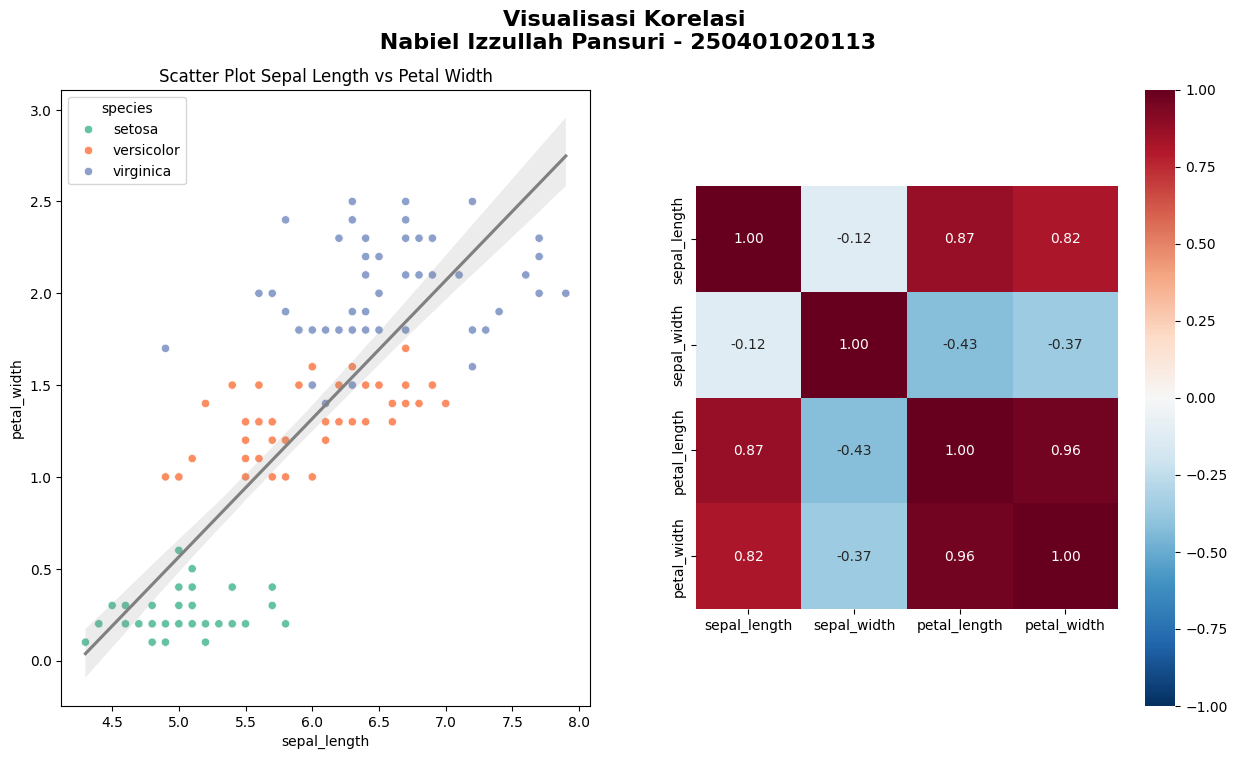

In [49]:
fig, ax = plt.subplots(1,2,figsize=(15,8))

fig.suptitle('Visualisasi Korelasi\n Nabiel Izzullah Pansuri - 250401020113', fontsize=16, fontweight='bold')
sns.scatterplot(data=df, x='sepal_length', y='petal_width', hue='species', palette='Set2', ax=ax[0])
sns.regplot(data=df, x='sepal_length', y='petal_width', scatter=False, ax=ax[0], color='gray')
ax[0].set_title('Scatter Plot Sepal Length vs Petal Width')

sns.heatmap(corr, annot=True, cmap='RdBu_r', vmin=-1,vmax=1, square=True, fmt='.2f', ax=ax[1])

# Interpretasi Scatter Plot & Heatmap #

Dari grafik diatas, didapati bahwa:
- Terdapat 2 hubungan korelasi positif dan 1 hubungan negatif
- Hubungan Antara *petal_width* dan *petal_length* memiliki korelasi tertinggi
- Hubungan antara *petal_length* dan *sepal_width* memiliki korelasi terendah

# Kesimpulan #

Berdasarkan praktikum di atas, didapati bahwa:
1. Dataset iris mempunyai 1 fitur kategorikal (spesies) dan 4 fitur numerikal.
2. Spesies Virginica memiliki ukuran petal terbesar.
3. Terdapat korelasi kuat antara petal_width dan petal_length, yang berarti semakin lebar mahkota, akan semakin panjang pula mahkotanya.
4. Setelah melakukan praktikum di atas, kita bisa memahami pola distribusi data dan korelasi antar variabel secara lebih jelas, dan dengan visualisasi kita bisa memahami data secara lebih jelas.